# RAG Agent

ReAct Agent에 Retriever를 Tool로 등록하면 **대화형 RAG**가 된다. 기본 RAG 파이프라인은 질문 하나에 검색 한 번, 답변 한 번이 전부였지만, Agent로 구성하면:

- 검색 없이 답변할 수 있는 질문은 **Tool 호출 생략**
- 여러 Tool을 등록하면 질문에 따라 **적절한 Tool을 선택**
- Checkpointer를 연결하면 **이전 대화를 기억**하면서 검색

| 구분 | 기본 RAG 파이프라인 | RAG Agent |
|------|----------|-----------|
| 검색 판단 | 항상 검색 | LLM이 필요 여부 판단 |
| 대화 기억 | 별도 구현 필요 | Checkpointer로 유지 |
| Tool 확장 | 어려움 | 웹 검색 등 Tool 추가 가능 |


In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Retriever를 Tool로 변환

RAG 강의에서 만든 Chroma 벡터스토어에 연결하고, `create_retriever_tool`로 Tool을 만든다. 이 함수는 retriever를 감싸서 ReAct Agent가 호출할 수 있는 Tool로 변환한다.

In [2]:
import chromadb
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

COLLECTION_NAME = "spri_ai_brief"
PERSIST_DIR = "./chroma_db"

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 기존 벡터스토어에 연결
vectorstore = Chroma(
    embedding_function=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Retriever를 Tool로 변환
retriever_tool = create_retriever_tool(
    retriever,
    name="search_ai_brief",
    description="SPRi AI Brief 문서에서 AI 산업 동향 정보를 검색한다. AI 관련 정책, 기업 동향, 기술 트렌드 등을 질문할 때 사용한다.",
)

print(f"Tool 이름: {retriever_tool.name}")
print(f"Tool 설명: {retriever_tool.description}")

Tool 이름: search_ai_brief
Tool 설명: SPRi AI Brief 문서에서 AI 산업 동향 정보를 검색한다. AI 관련 정책, 기업 동향, 기술 트렌드 등을 질문할 때 사용한다.


`create_retriever_tool`이 하는 일:
1. retriever의 `invoke(query)`를 호출하는 함수를 만든다
2. 검색된 Document들의 `page_content`를 합쳐서 문자열로 반환한다
3. `name`과 `description`으로 LLM이 이 Tool을 언제 사용할지 판단한다

`description`이 중요하다. LLM은 이 설명을 보고 Tool 호출 여부를 결정하므로, **어떤 정보가 들어있는지** 구체적으로 작성해야 한다.

## RAG Agent 구현

Retriever Tool을 ReAct Agent에 등록한다. `create_agent`를 사용하면 표준 ReAct 패턴을 한 줄로 만들 수 있다.

```python
# StateGraph로 직접 구성
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph = graph_builder.compile()

# create_agent로 동일한 그래프를 한 줄로 생성
graph = create_agent(model=llm, tools=tools)
```

내부적으로 동일한 구조(`chatbot → tools_condition → ToolNode → chatbot → ...`)가 만들어진다. 커스텀 노드나 분기가 필요 없는 표준 ReAct 패턴이면 `create_agent`가 간결하다. 이후 강의에서 Router, Reflection 같은 커스텀 구조가 필요한 패턴은 다시 `StateGraph`로 직접 구성한다.

In [3]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

graph = create_agent(model=llm, tools=[retriever_tool])

print("RAG Agent 생성 완료")

RAG Agent 생성 완료


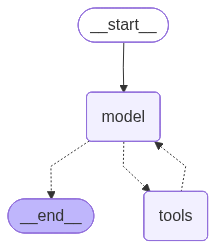

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 테스트

기존 RAG와의 차이를 확인한다. Agent는 질문에 따라 **검색 여부를 스스로 판단**한다.

In [5]:
# 문서 검색이 필요한 질문
question = "AI 반도체 관련 최근 동향을 알려줘"

for event in graph.stream({"messages": [("user", question)]}):
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.content[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print(f"  Tool 호출: {[tc['name'] for tc in last_msg.tool_calls]}")
        print()

[model] ai: 
  Tool 호출: ['search_ai_brief']

[tools] tool: | 2025년 9월호 |
기술･연구

정책･법제기업･산업기술･연구인력･교육
13
구글 클라우드, 데이터 분석에 특화된 AI 에이전트 제품군 발표n구글 클라우드가 복잡한 데이터 업무의 간소화와 자동화를 지원하는 데이터 에이전트 제품군과 에이전트 생태계의 확장성과 연결성을 지원하는 데이터 에이전트 API를 발표n구글은 제미나이 2.5 프로의 고급 추론 기능을 

[model] ai: 최근 AI 반도체 관련 동향은 다음과 같습니다:

1. **구글 클라우드의 AI 에이전트 제품군 발표**: 구글 클라우드는 데이터 분석에 특화된 AI 에이전트 제품군을 발표했습니다. 이 제품군은 복잡한 데이터 업무의 간소화와 자동화를 지원하며, 데이터 에이전트 API를 통해 생태계의 확장성과 연결성을 강화합니다. 특히, 제미나이 2.5 프로의 고급 추론 기



In [6]:
# 검색 없이 답변 가능한 질문
question = "안녕하세요!"

for event in graph.stream({"messages": [("user", question)]}):
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.content[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            print(f"  Tool 호출: {[tc['name'] for tc in last_msg.tool_calls]}")
        print()

[model] ai: 안녕하세요! 어떻게 도와드릴까요?



첫 번째 질문에서는 `search_ai_brief` Tool을 호출하고, 두 번째 질문에서는 Tool 호출 없이 바로 응답한다. 기존 RAG 파이프라인은 모든 질문에 대해 무조건 검색을 수행하지만, Agent는 **검색이 필요한 경우에만** Tool을 호출한다.

### 문서 기반 답변만 허용하기

RAG Agent는 검색 결과가 없거나 부족해도 LLM의 일반 지식으로 답변할 수 있다. 하지만 사내 문서 QA, 고객 응대 봇처럼 **승인된 문서에 근거한 답변만** 허용해야 하는 경우도 많다. 이때는 System Prompt로 제어한다.

In [7]:
strict_rag_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt="너는 AI 산업 문서 기반 QA 봇이다. 사용자가 질문하면 반드시 search_ai_brief 도구로 먼저 검색하라. 검색 결과에 관련 정보가 있으면 그 내용을 기반으로 답변하고, 관련 정보가 없으면 '해당 정보를 문서에서 찾을 수 없습니다.'라고 답하라. 문서에 없는 내용을 추측하거나 일반 지식으로 답변하지 마라.",
)

print("문서 기반 RAG Agent 생성 완료")

문서 기반 RAG Agent 생성 완료


In [8]:
# 문서에 없는 내용을 질문
result = strict_rag_agent.invoke(
    {"messages": [("user", "오늘 날씨 어때?")]}
)
print("질문: 오늘 날씨 어때?")
print(f"답변: {result['messages'][-1].content}")
print()

# 문서에 있는 내용을 질문
result = strict_rag_agent.invoke(
    {"messages": [("user", "AI 관련 최신 동향을 알려줘")]}
)
print("질문: AI 관련 최신 동향을 알려줘")
print(f"답변: {result['messages'][-1].content[:300]}")

질문: 오늘 날씨 어때?
답변: 해당 정보를 문서에서 찾을 수 없습니다.

질문: AI 관련 최신 동향을 알려줘
답변: 최근 AI 산업의 동향에 따르면, 2025년 AI 하이프 사이클이 발표되었습니다. 이 사이클에서는 운영 확장성과 실시간 인텔리전스 확보를 위한 AI 활용이 주목받고 있으며, AI 에이전트와 AI에 준비된 데이터가 급부상하고 있습니다. 또한, 가트너는 향후 5년 안에 주류로 부상할 AI 혁신 기술로 멀티모달 AI와 AI TRiSM(신뢰, 위험, 보안 관리) 프레임워크를 선정했습니다.

기술 및 연구 분야에서는 구글 딥마이드가 차세대 월드 모델 '지니 3'를 공개하였고, 엔비디아는 시그라프 2025에서 피지컬 AI의 최신 연구 성과를 


System Prompt 하나로 Agent의 동작이 달라진다:
- 문서에 없는 질문 → 검색 후 관련 내용이 없으면 "찾을 수 없습니다"로 거절
- 문서에 있는 질문 → 검색 결과 기반으로 답변

용도에 따라 선택하면 된다:
- **개방형**: System Prompt 없이 사용. 문서 + 일반 지식으로 폭넓게 답변
- **제한형**: System Prompt로 문서 기반 답변만 허용. 정확성이 중요한 경우

## 대화형 RAG Agent

Checkpointer를 연결하면 이전 대화를 기억하는 RAG 챗봇이 된다. "아까 검색한 내용에서 더 알려줘"같은 후속 질문이 가능해진다.

In [9]:
from langgraph.checkpoint.memory import MemorySaver

rag_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    checkpointer=MemorySaver(),
)

print("대화형 RAG Agent 생성 완료")

대화형 RAG Agent 생성 완료


In [10]:
config = {"configurable": {"thread_id": "rag-session-1"}}

# 첫 번째 질문: 문서 검색
result = rag_agent.invoke(
    {"messages": [("user", "구글 제미나이 관련 동향을 알려줘")]},
    config=config,
)
print(result["messages"][-1].content)

구글 제미나이에 대한 최근 동향은 다음과 같습니다:

1. **제미나이 2.5 딥씽크 출시**: 구글은 제미나이 앱에서 '제미나이 2.5 딥씽크'라는 새로운 AI 모델을 발표했습니다. 이 모델은 최상위 요금제인 구글 AI 울트라 구독자에게 제공되며, 병렬 사고 기법을 통해 여러 아이디어를 검토하여 최적의 답을 도출하는 데 특화되어 있습니다.

2. **성능 개선**: 제미나이 2.5 딥씽크는 2025년 5월 I/O에서 처음 공개된 이후 벤치마크 성능과 테스터 피드백을 바탕으로 상당한 개선이 이루어졌습니다. 이 모델은 2025 국제수학올림피아드(IMO)에서 금메달을 획득한 모델의 변형 버전으로, 내부 평가에서 동메달 수준의 성능을 달성했습니다.

3. **안전성 및 응답 거부 경향**: 제미나이 2.5 딥씽크는 이미지-텍스트 안전성과 응답 거부 시의 톤이 개선되었으나, 무해한 요청을 거부하는 경향이 증가했습니다. 응답 거부 톤은 16.3% 개선되었지만, 지시 이행 비율은 9.9% 감소하여 무해한 요청을 거부하는 사례가 늘어났습니다.

4. **안전 조치**: 구글은 제미나이 2.5 딥씽크의 위험 완화를 위해 데이터셋 필터링, 사전학습, 감독 미세조정, 인간 피드백을 통한 강화학습, 안전 정책 수립 등의 안전 조치를 취하고 있습니다.

이러한 동향은 구글이 AI 모델의 성능과 안전성을 동시에 개선하기 위해 노력하고 있음을 보여줍니다.


In [11]:
# 두 번째 질문: 이전 대화를 기억한 후속 질문
result = rag_agent.invoke(
    {"messages": [("user", "그 중에서 가장 중요한 것 하나만 골라줘")]},
    config=config,
)
print(result["messages"][-1].content)

가장 중요한 동향은 **제미나이 2.5 딥씽크의 출시**입니다. 이 모델은 병렬 사고 기법을 통해 여러 아이디어를 검토하여 최적의 답을 도출하는 데 특화되어 있으며, 구글 AI 울트라 구독자에게 제공됩니다. 이는 구글의 AI 기술 발전과 사용자 경험 향상에 중요한 이정표가 될 것으로 보입니다.


In [12]:
# 세 번째 질문: 검색 없이 대화 맥락으로 답변
result = rag_agent.invoke(
    {"messages": [("user", "위 내용을 영어로 번역해줘")]},
    config=config,
)
print(result["messages"][-1].content)

The most important trend is the **launch of Gemini 2.5 Deep Think**. This model is specialized in parallel thinking techniques to evaluate multiple ideas and derive optimal answers, and it is offered to Google AI Ultra subscribers. This represents a significant milestone in the advancement of Google's AI technology and the enhancement of user experience.


대화 흐름:
1. "구글 제미나이 동향" → `search_ai_brief` Tool 호출 → 문서 기반 답변
2. "가장 중요한 것 하나만" → 이전 답변 맥락에서 선별 (Tool 호출 없이 처리)
3. "영어로 번역" → Tool 호출 없이 대화 맥락으로 처리

Checkpointer가 없었다면 2, 3번 질문에서 "무슨 내용인지 모르겠다"고 답했을 것이다.

## 하이브리드 Agent: RAG + 웹 검색

문서에 없는 최신 정보는 웹 검색으로 보완할 수 있다. Retriever Tool과 웹 검색 Tool을 함께 등록하면, Agent가 질문에 따라 적절한 Tool을 선택한다.

In [13]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results=3)

hybrid_agent = create_agent(
    model=llm,
    tools=[retriever_tool, search],
    checkpointer=MemorySaver(),
)

print("하이브리드 Agent 생성 완료")

하이브리드 Agent 생성 완료


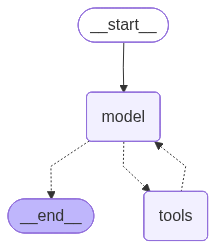

In [14]:
display(Image(hybrid_agent.get_graph().draw_mermaid_png()))

In [15]:
config = {"configurable": {"thread_id": "hybrid-session-1"}}

# 내부 문서 검색 → search_ai_brief 호출
result = hybrid_agent.invoke(
    {"messages": [("user", "AI Brief 문서에서 엔비디아 관련 내용을 찾아줘")]},
    config=config,
)
print(result["messages"][-1].content)
print()

# 최신 정보 검색 → tavily_search 호출
result = hybrid_agent.invoke(
    {"messages": [("user", "오늘 엔비디아 주가는 얼마야?")]},
    config=config,
)
print(result["messages"][-1].content)

엔비디아는 최근 '시그라프 2025' 행사에서 피지컬 AI에 특화된 시각언어모델인 '코스모스 리즌'과 '엔비디아 네모트론' 추론 모델을 발표했습니다. 이 모델들은 2D 이미지나 동영상 기반의 3D 기하구조 재구성, 시뮬레이션, AI 기반 렌더링, 3D 콘텐츠 생성 분야의 최신 연구 성과를 포함하고 있습니다.

- **코스모스 리즌**: 매개변수 70억 개의 개방형 추론 시각언어모델(VLM)로, 로봇과 시각 AI 에이전트가 사전 지식과 물리 법칙, 상식을 바탕으로 인간처럼 추론하고 실제 세계를 이해할 수 있도록 지원합니다. 이 모델은 시각적 정보와 언어 정보를 복합적으로 처리하여 이미지 및 영상 인식과 추론을 지원합니다.

- **엔비디아 네모트론**: 새로운 모델인 '엔비디아 네모트론 나노 2'와 '라마 네모트론 수퍼 1.5'는 추론, 수학, 코딩, 도구 호출, 지시 수행 및 대화에 특화되어 AI 에이전트가 더욱 깊이 생각하고 효율적으로 작업할 수 있도록 돕습니다.

이와 함께, 엔비디아는 대규모 3D 공간 재구성을 위한 합성 데이터 생성 라이브러리인 '옴니버스 누렉'도 발표했습니다. 이러한 연구 성과들은 물리적 사실성을 개선하고 AI 모델 개발을 촉진하는 데 기여하고 있습니다.

현재 엔비디아(NVDA)의 주가는 실시간으로 확인할 수 있는 금융 웹사이트에서 확인할 수 있습니다. 예를 들어, [Yahoo Finance](https://finance.yahoo.com/)를 방문하시면 엔비디아의 최신 주가 정보를 확인할 수 있습니다. 

주가는 시장 상황에 따라 변동하므로, 정확한 정보를 원하시면 해당 링크를 통해 직접 확인하시기 바랍니다.


LangSmith에서 각 호출의 트레이스를 확인하면, 첫 번째 질문은 `search_ai_brief`, 두 번째 질문은 `tavily_search`를 호출한 것을 볼 수 있다. Agent가 Tool의 `description`을 보고 판단한다:
- "AI Brief 문서에서" → `search_ai_brief` (내부 문서 검색)
- "오늘 주가" → `tavily_search` (실시간 웹 검색)

Tool을 추가하는 것만으로 Agent의 능력이 확장된다. 이것이 Agent 기반 RAG의 핵심 장점이다.

## 실습 문제

RAG 강의에서 만든 벡터스토어(또는 새로운 문서)를 활용하여 다음 요구사항을 만족하는 대화형 RAG Agent를 구성하라.

**요구사항**:
1. Retriever Tool과 웹 검색 Tool을 모두 등록한다
2. Checkpointer를 연결하여 대화를 기억한다
3. System Prompt를 추가하여 Agent의 역할을 지정한다 (예: "너는 AI 산업 전문 분석가야")
수 있다.